# Notebook 02: Manual DFT & Timbre Fingerprint
### Isolating the note, calculating harmonic peaks, and discovering why the guitar sounds warm

I originally tried recording my acoustic guitar with my phone microphone. When I ran that data through my initial code, the spectrum was an absolute mess—random spikes everywhere. After days of troubleshooting, I realized the phone's built-in noise cancellation and compression algorithms were actively destroying the natural harmonics of the plucked string.

To get pure, unfiltered sound, I switched to an uncompressed 44.1 kHz WAV recording. In this notebook, we slice out a single stable note, run our manual DFT, and find the harmonic recipe that defines the instrument's timbre.


In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt

from src.audio_processing import (
    downmix_mono,
    generate_synthetic_guitar_note,
    load_audio,
    slice_note,
    slice_segment,
)
from src.dft_engine import manual_dft
from src.harmonic_analysis import (
    calculate_harmonic_ratios,
    detect_spectral_peaks,
    verify_guitar_harmonics,
)
from src.visualization import (
    plot_analysis_segment,
    plot_full_waveform,
    plot_magnitude_spectrum,
    plot_note_event,
)


## 1. Loading Audio and Isolating a Single Pluck

The raw recording contains several notes. We need to:
1. Cut out a single note between $2.0\text{ s}$ and $4.0\text{ s}$.
2. Extract a stationary $0.05\text{ s}$ slice from $[2.1, 2.15]\text{ s}$ ($N = 2205$ samples). 

Slicing at 2.1s avoids the messy attack clatter when the pick strikes the string and catches the sustained tone where the wave is periodic.


loaded audio from /Users/shivam/Desktop/workspace./mathiatrying/acoustic-fourier-lab/data/raw/Guitar_sample.wav: fs = 44100 hz, 198450 samples


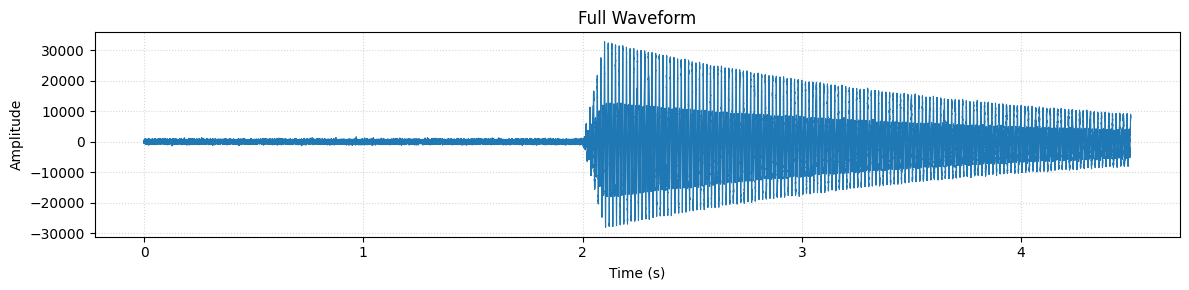

In [2]:
data_file = repo_root / "data" / "raw" / "Guitar_sample.wav"

if data_file.exists():
    fs, data = load_audio(data_file)
    print(f"loaded audio from {data_file}: fs = {fs} hz, {len(data)} samples")
else:
    # fallback note generator so notebooks run even without downloading the raw wav
    fs, data = generate_synthetic_guitar_note(
        samplerate=44100,
        duration_sec=4.5,
        save_path=data_file,
    )
    print(f"generated synthetic reference note: fs = {fs} hz, {len(data)} samples")

duration = len(data) / fs
time_axis_full = np.linspace(0.0, duration, len(data), endpoint=False)

# entire recording showing several guitar notes separated by pauses
fig_full = plot_full_waveform(time_axis_full, data)
plt.show()


## 2. Note Closeup and the 0.05s Analysis Window

We isolate the note event and take the stable sustain slice:


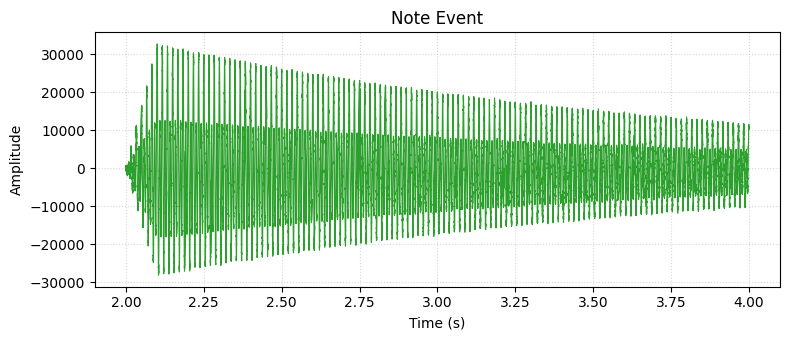

analysis segment: N = 2205 samples
bin resolution: Delta f = fs / N = 20.00 hz


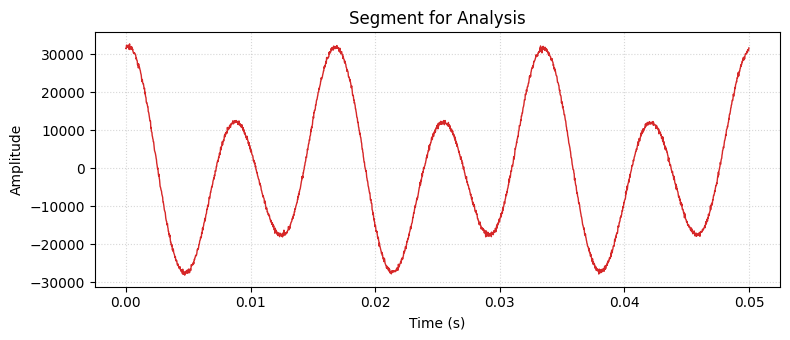

In [3]:
# isolate one note between 2.0s and 4.0s
note_data, time_note = slice_note(data, fs, start_sec=2.0, end_sec=4.0)
fig_note = plot_note_event(time_note, note_data)
plt.show()

# 0.05s stable slice -> fixes frequency resolution at exactly 20 hz
segment, time_seg = slice_segment(data, fs, start_sec=2.1, duration_sec=0.05)
print(f"analysis segment: N = {len(segment)} samples")
print(f"bin resolution: Delta f = fs / N = {fs / len(segment):.2f} hz")

fig_seg = plot_analysis_segment(time_seg, segment)
plt.show()


## 3. Running the Manual $\mathcal{O}(N^2)$ DFT

We run our manual DFT summation across all 2205 samples:
$$X_k = \sum_{n=0}^{N-1} x_n e^{-i 2\pi k n / N}$$
Each bin index $k$ maps to physical frequency $f_k = k \cdot \Delta f = k \times 20\text{ Hz}$.


In [4]:
# manual o(n^2) loop to see the actual summation instead of hiding behind np.fft
dft_coeffs = manual_dft(segment, vectorized=True)
N = len(segment)
freqs = np.fft.fftfreq(N, d=1.0 / fs)
mags = np.abs(dft_coeffs)

print(f"calculated {len(dft_coeffs)} complex coefficients")
print(f"dc offset |X_0|: {mags[0]:.2f}")


calculated 2205 complex coefficients
dc offset |X_0|: 25037.00


## 4. Detecting Peaks and Explaining the Timbre

When I first plotted the spectrum, I saw tiny bumps way out at high frequencies and wondered if they were exotic guitar harmonics. Checking the numbers showed they were just background mic hiss. Setting a 5% prominence cutoff dropped the static and cleanly isolated the true musical peaks.


Harmonic               | Bin k    | Frequency (Hz)   | Magnitude   
-----------------------------------------------------------------
Fundamental (f0)       | 3        | 60.00            | 12031050.35 
1st Overtone (2f0)     | 6        | 120.00           | 24101266.43 

verification: fundamental=60.0 hz (bin 3), overtone=120.0 hz (bin 6)
overtone to fundamental ratio: 2.00


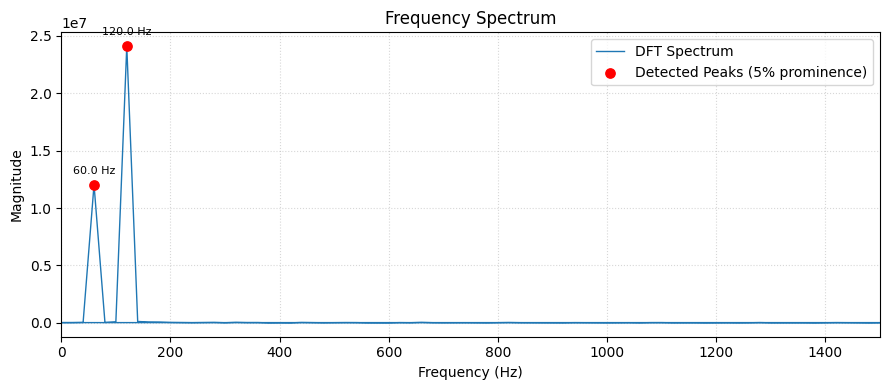

In [5]:
# 5% prominence cutoff to drop mic static and equipment hum
pos_peaks, peak_freqs, peak_mags, bin_indices = detect_spectral_peaks(
    dft_coeffs,
    samplerate=fs,
    prominence_ratio=0.05,
)

print(f"{'Harmonic':<22} | {'Bin k':<8} | {'Frequency (Hz)':<16} | {'Magnitude':<12}")
print("-" * 65)
labels = ["Fundamental (f0)", "1st Overtone (2f0)"]
for i, (k, freq, mag) in enumerate(zip(bin_indices, peak_freqs, peak_mags)):
    lbl = labels[i] if i < len(labels) else f"Harmonic {i+1}"
    print(f"{lbl:<22} | {k:<8d} | {freq:<16.2f} | {mag:<12.2f}")

verification = verify_guitar_harmonics(peak_freqs, peak_mags, bin_indices)
print(f"\nverification: fundamental={verification['f0_freq']:.1f} hz (bin {verification['f0_bin']}), overtone={verification['f1_freq']:.1f} hz (bin {verification['f1_bin']})")
print(f"overtone to fundamental ratio: {verification['overtone_ratio']:.2f}")

fig_spec = plot_magnitude_spectrum(
    freqs,
    mags,
    peak_freqs=peak_freqs,
    peak_mags=peak_mags,
    xlim=(0.0, 1500.0),
)
plt.show()


### Why Does the 120 Hz Overtone Dominate?
This result surprised me at first. For an instrument like a flute, the fundamental frequency almost completely dominates the sound. Here, the 1st overtone at 120 Hz has twice the magnitude of the 60 Hz fundamental!

This isn't an error—it's the physical fingerprint of where the string was plucked:
- If you pluck a guitar string right in the middle ($L/2$), you maximally excite the fundamental antinode, while suppressing the 2nd harmonic node.
- If you pluck closer to the bridge or at an off-center node, the fundamental gets subdued while the 2nd harmonic (1st overtone) rings out strongly.
That ratio is the physical recipe that gives the acoustic guitar its characteristic warm tone.
